In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [33]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (10000, 14)

Column names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 1

In [35]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [36]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [37]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [38]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


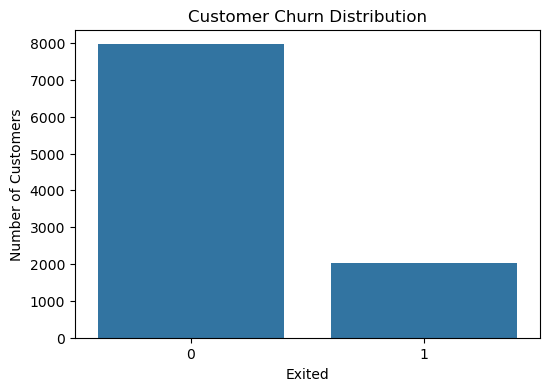

In [39]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [40]:
print(df["Exited"].value_counts(normalize=True) * 100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [41]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [42]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [43]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [44]:
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

categorical_features = [
    "Geography",
    "Gender"
]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [47]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [48]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [50]:
print("Logistic Regression")
print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
--------------------
Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1 Score : 0.2835820895522388
ROC-AUC  : 0.7748009951399782


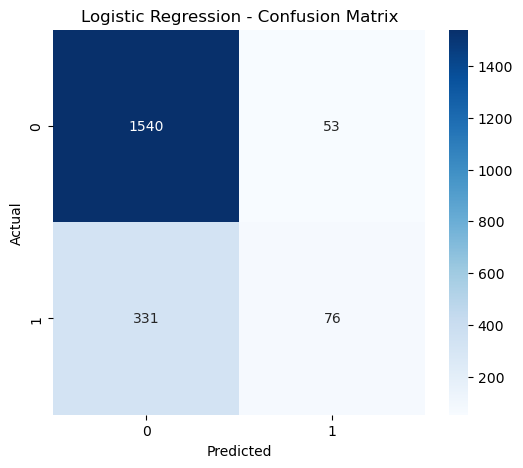

In [51]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

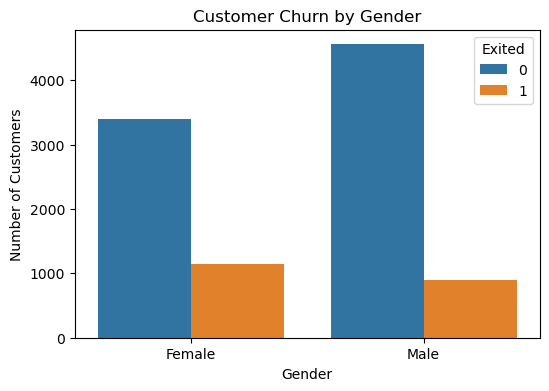

In [52]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Gender", hue="Exited", data=df)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

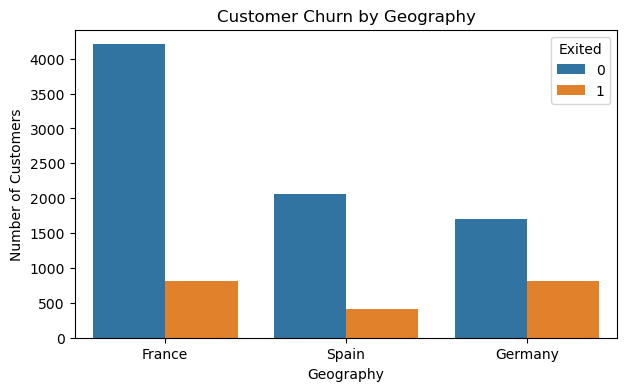

In [53]:
plt.figure(figsize=(7, 4))

sns.countplot(x="Geography", hue="Exited", data=df)

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.show()

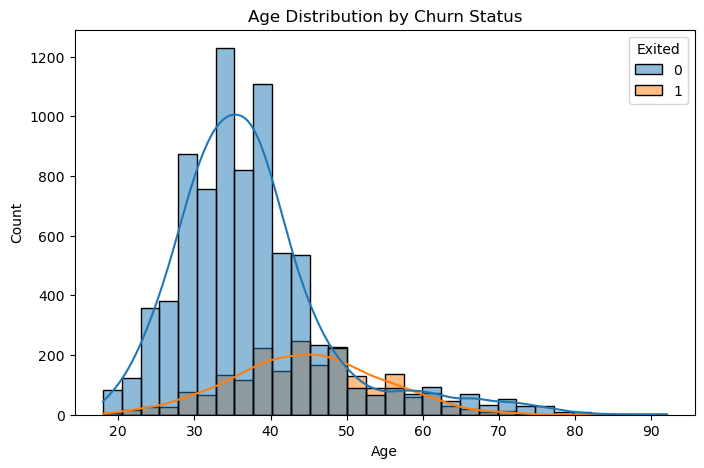

In [54]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", hue="Exited", kde=True, bins=30)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

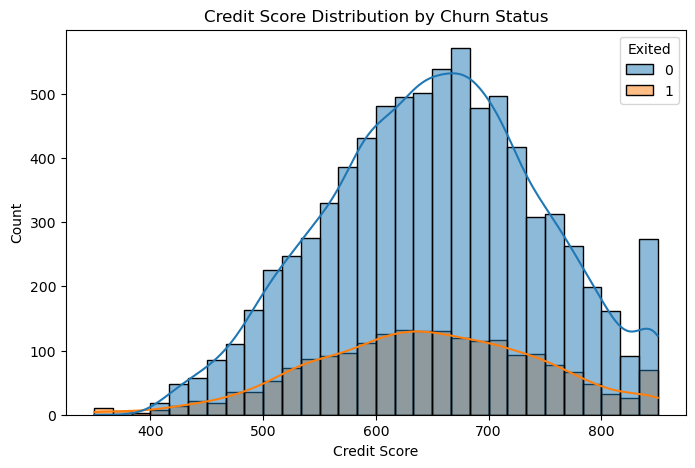

In [55]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="CreditScore", hue="Exited", kde=True, bins=30)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

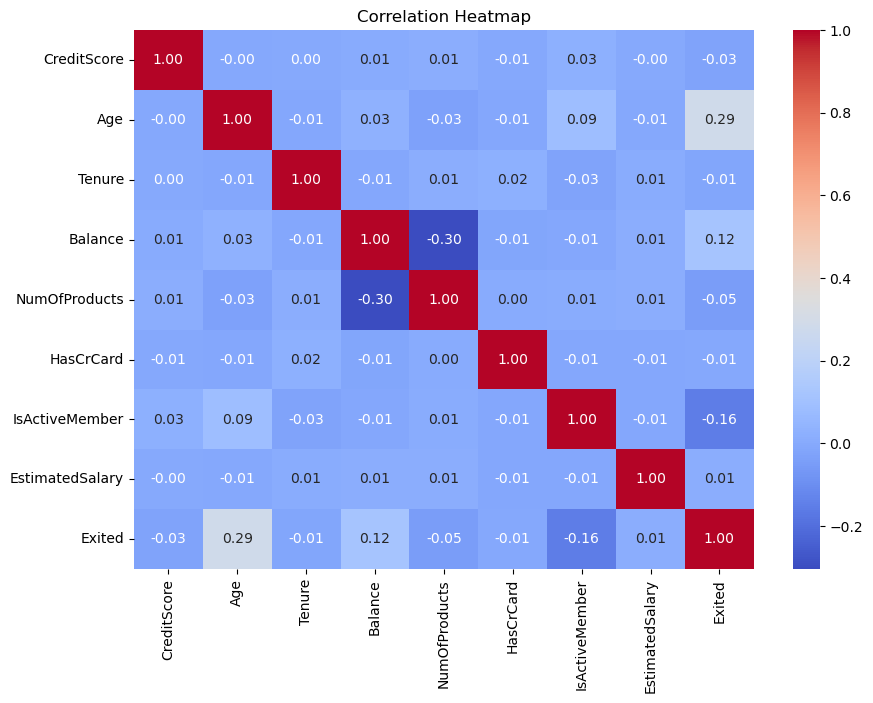

In [56]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()